In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split

In [67]:
df=pd.read_csv('atm_cash_management_dataset.csv')
df

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,ATM_0029,2022-07-02,Saturday,Night,32027,3097,Standalone,0,0,96493,Clear,2,35148
5654,ATM_0050,2023-12-08,Friday,Afternoon,60120,4948,Mall,0,0,128933,Rainy,5,51927
5655,ATM_0036,2022-10-04,Tuesday,Evening,32551,10819,Mall,0,0,104519,Snowy,3,31127
5656,ATM_0010,2022-04-19,Tuesday,Night,52965,13372,Gas Station,0,0,107829,Rainy,2,35886


In [68]:
df.shape

(5658, 13)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5658 entries, 0 to 5657
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ATM_ID                   5658 non-null   object
 1   Date                     5658 non-null   object
 2   Day_of_Week              5658 non-null   object
 3   Time_of_Day              5658 non-null   object
 4   Total_Withdrawals        5658 non-null   int64 
 5   Total_Deposits           5658 non-null   int64 
 6   Location_Type            5658 non-null   object
 7   Holiday_Flag             5658 non-null   int64 
 8   Special_Event_Flag       5658 non-null   int64 
 9   Previous_Day_Cash_Level  5658 non-null   int64 
 10  Weather_Condition        5658 non-null   object
 11  Nearby_Competitor_ATMs   5658 non-null   int64 
 12  Cash_Demand_Next_Day     5658 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 574.8+ KB


In [70]:
df.describe()

,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
count,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000
mean,49808.106928,10129.078473,0.022093,0.096501,100283.994698,2.477731,43085.207494
std,14903.539241,4878.853583,0.146998,0.295303,20122.365608,1.719487,16797.100086
min,1380.000000,0.000000,0.000000,0.000000,23266.000000,0.000000,0.000000
25%,39469.250000,6765.000000,0.000000,0.000000,86533.500000,1.000000,31558.750000
50%,50039.000000,10048.000000,0.000000,0.000000,100276.500000,2.000000,42589.500000
75%,60132.500000,13430.000000,0.000000,0.000000,113956.500000,4.000000,53831.000000
max,107790.000000,32395.000000,1.000000,1.000000,172227.000000,5.000000,114724.000000


In [71]:
uniqueness = df.nunique(dropna=False).sort_values(ascending=False)
print(uniqueness)

Previous_Day_Cash_Level    5452
Cash_Demand_Next_Day       5363
Total_Withdrawals          5347
Total_Deposits             4723
Date                        731
ATM_ID                       50
Day_of_Week                   7
Nearby_Competitor_ATMs        6
Location_Type                 5
Time_of_Day                   4
Weather_Condition             4
Special_Event_Flag            2
Holiday_Flag                  2
dtype: int64


In [72]:
n_rows=len(df)
unique_cols=[c for c in df.columns if df[c].nunique(dropna=False)==n_rows]
unique_cols

[]

In [73]:
n_rows=len(df)
unique_cols=[c for c in df.columns if df[c].nunique(dropna=False)>0.95*n_rows]
unique_cols

['Previous_Day_Cash_Level']

In [74]:
df=df.drop(columns=['Previous_Day_Cash_Level'])
df

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,Snowy,0,29784
...,...,...,...,...,...,...,...,...,...,...,...,...
5653,ATM_0029,2022-07-02,Saturday,Night,32027,3097,Standalone,0,0,Clear,2,35148
5654,ATM_0050,2023-12-08,Friday,Afternoon,60120,4948,Mall,0,0,Rainy,5,51927
5655,ATM_0036,2022-10-04,Tuesday,Evening,32551,10819,Mall,0,0,Snowy,3,31127
5656,ATM_0010,2022-04-19,Tuesday,Night,52965,13372,Gas Station,0,0,Rainy,2,35886


In [75]:
df.isna().sum()

ATM_ID                    0
Date                      0
Day_of_Week               0
Time_of_Day               0
Total_Withdrawals         0
Total_Deposits            0
Location_Type             0
Holiday_Flag              0
Special_Event_Flag        0
Weather_Condition         0
Nearby_Competitor_ATMs    0
Cash_Demand_Next_Day      0
dtype: int64

In [76]:
numeric_cols = df.select_dtypes(include=['float64', 'int64','int32']).columns
def detect_outliers(df, column):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

outliers_summary = {}
for col in numeric_cols:
    outliers = detect_outliers(df, col)
    outliers_summary[col] = len(outliers)

print("Outliers in numeric columns:")
print(outliers_summary)

Outliers in numeric columns:
{'Total_Withdrawals': 0, 'Total_Deposits': 0, 'Holiday_Flag': 125, 'Special_Event_Flag': 546, 'Nearby_Competitor_ATMs': 0, 'Cash_Demand_Next_Day': 0}


In [77]:
dupicates=df[df.duplicated()]
print(f'Total dupicates: {dupicates.shape[0]}')

Total dupicates: 0


In [78]:
for col in df:
    df[col]=LabelEncoder().fit_transform(df[col])
df.head()

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,40,114,1,2,3680,2011,3,0,0,2,5,2840
1,6,692,0,2,5014,4383,4,0,0,0,0,2490
2,13,238,2,2,1754,3242,4,0,0,1,1,1179
3,28,603,3,1,1761,92,2,0,0,2,5,2839
4,27,348,4,1,1018,279,0,0,0,3,0,1168


In [79]:
df

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,40,114,1,2,3680,2011,3,0,0,2,5,2840
1,6,692,0,2,5014,4383,4,0,0,0,0,2490
2,13,238,2,2,1754,3242,4,0,0,1,1,1179
3,28,603,3,1,1761,92,2,0,0,2,5,2839
4,27,348,4,1,1018,279,0,0,0,3,0,1168
...,...,...,...,...,...,...,...,...,...,...,...,...
5653,28,182,2,3,636,308,3,0,0,0,2,1746
5654,49,706,0,0,3991,672,2,0,0,2,5,3777
5655,35,276,5,1,675,2573,2,0,0,3,3,1302
5656,9,108,5,3,3116,3437,1,0,0,2,2,1842


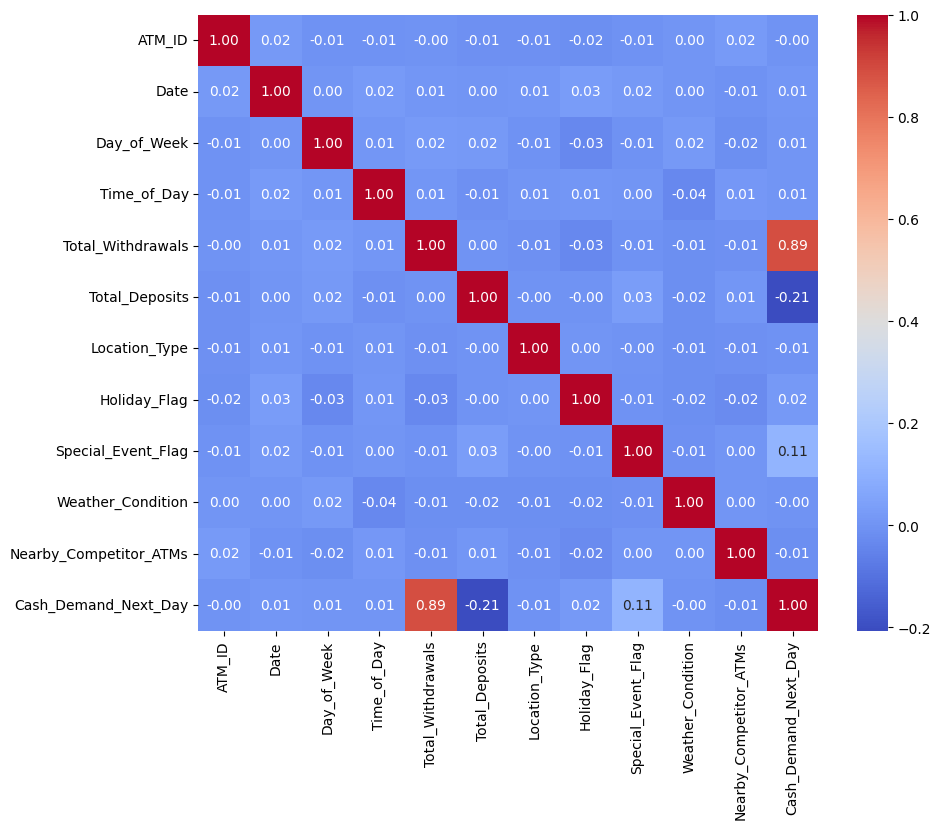

In [80]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',fmt=".2f")
plt.show()

Define target and split the table

In [81]:
y = df['Cash_Demand_Next_Day']
X = df.drop(columns=['Cash_Demand_Next_Day'])

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Linear Regression

In [83]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [84]:
print(pred_lr)

[2962.51068458 5376.95767316 2668.11811633 ... 4042.00032851 2892.03961989
 3133.19531203]


In [92]:
X_test['actual']=y_test

In [93]:
X_test['pred']=pred_lr

In [94]:
X_test['residual']=X_test.actual-X_test.pred

In [95]:
X_test

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Weather_Condition,Nearby_Competitor_ATMs,actual,pred,residual
3803,35,355,4,1,3640,4243,4,0,0,1,3,3603,2962.510685,640.489315
5098,46,721,2,0,4893,1708,0,0,1,2,2,5211,5376.957673,-165.957673
3691,46,547,3,1,2606,1693,0,0,0,2,5,3521,2668.118116,852.881884
1499,10,585,6,0,1032,1724,4,0,0,1,4,855,1235.654773,-380.654773
3296,9,189,2,1,1414,4630,2,0,0,2,1,877,926.679168,-49.679168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4954,23,699,0,0,1113,4205,0,1,0,0,1,1094,1228.835843,-134.835843
1071,12,300,0,3,3016,3965,1,0,0,3,4,2669,2524.621082,144.378918
718,47,350,2,2,3155,656,4,0,1,1,2,4566,4042.000329,523.999671
4105,23,44,1,2,3399,3817,4,0,0,3,4,3861,2892.039620,968.960380


Decision Tree

In [85]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

Random Forest

In [86]:
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

Gradient Boosting

In [87]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

XGB Regressor

In [88]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [89]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def evaluate(y_test, pred, model_name):

    r2 = r2_score(y_test, pred)
    accuracy = r2 * 100
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    return {
        "Model": model_name,
        "Accuracy (%)": round(accuracy, 2),
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    }

Compare All Models

In [90]:
results = []

results.append(evaluate(y_test, pred_rf, "Linear Regression"))
results.append(evaluate(y_test, pred_dt, "Decision Tree"))
results.append(evaluate(y_test, pred_rf, "Random Forest"))
results.append(evaluate(y_test, pred_gb, "Gradient Boosting"))
results.append(evaluate(y_test, pred_xgb, "XGBoost"))

Convert Into Table

In [91]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy (%),R2 Score,MAE,RMSE
0,Linear Regression,85.43,0.854319,475.717235,591.567843
1,Decision Tree,70.42,0.704242,644.113074,842.891298
2,Random Forest,85.43,0.854319,475.717235,591.567843
3,Gradient Boosting,86.47,0.864677,460.053558,570.149945
4,XGBoost,85.30,0.852987,472.994476,594.266749


## Model tuning

GridSearchCV

In [88]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# create model
model = RandomForestRegressor()

# parameters
param_grid = {
    'n_estimators': [100, 200,300],
    'max_depth': [5, 10,15],
    'min_samples_split': [2, 5,8]
}

# grid search
grid = GridSearchCV(model, param_grid, cv=5, scoring='r2')

# training
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 8, 'n_estimators': 300}


cross valedation

In [268]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Regularization Tuning

Ridge

In [85]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [86]:
y_pred = ridge_model.predict(X_test)

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(ridge,
                    param_grid,
                    cv=5,
                    scoring='r2')

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)

Best Alpha: {'alpha': 1}
